# 01 — Point Forecast Evaluation

Loads all model predictions, computes RMSE/MAE, produces comparison tables
and plots, and runs the Diebold-Mariano test with HLN small-sample correction.

**Input:** one `*_predictions.csv` per model (produced by the model scripts).

**Output:**
- `results/comparison/`: raw and relative RMSE/MAE tables, ranking, plots
- `results/diebold_mariano/`: DM results, pairwise heatmaps, publication tables

**Prerequisite:** all model scripts must have been run and their CSVs
available in their respective `results/<model>/` folders.


## Block 1 — Imports and Paths

In [1]:
# =============================================================================
# IMPORTS AND PATHS
# Single source of truth for constants and helper functions: nowcast_utils.py
# =============================================================================

import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

# Selective warning filters: see what we care about, silence only noise
warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

BASE_DIR  = Path.home() / "Desktop" / "ESA-gdp-nowcasting"
MODEL_DIR = BASE_DIR / "Models"
RES_DIR   = MODEL_DIR / "results"
OUT_COMP  = RES_DIR / "comparison"
OUT_DM    = RES_DIR / "diebold_mariano"
OUT_COMP.mkdir(parents=True, exist_ok=True)
OUT_DM.mkdir(parents=True, exist_ok=True)

# Import canonical constants and functions from nowcast_utils
sys.path.insert(0, str(MODEL_DIR))
from nowcast_utils import (
    LAGS, TARGET_VARIABLE,
    TRAIN_START, TEST_START, TEST_END,
    CRISIS_START, CRISIS_END,
    NORMAL_START, NORMAL_END,
    GDP_PUB_LAG, RANDOM_SEED,
    classify_crisis_periods,
    rmse, mae,
    diebold_mariano_test,
)

print("Paths ready.")
print(f"  comparison     : {OUT_COMP}")
print(f"  diebold_mariano: {OUT_DM}")
print(f"  Test window    : {TEST_START} to {TEST_END}")
print(f"  Vintages       : {LAGS}")
print(f"  Crisis window  : {CRISIS_START} to {CRISIS_END}")
print(f"  Normal window  : {NORMAL_START} to {NORMAL_END}")


Paths ready.
  comparison     : /Users/gabrielaaquino/Desktop/ESA-gdp-nowcasting/Models/results/comparison
  diebold_mariano: /Users/gabrielaaquino/Desktop/ESA-gdp-nowcasting/Models/results/diebold_mariano
  Test window    : 2020-03-01 to 2024-06-01
  Vintages       : [-2, -1, 0]
  Crisis window  : 2020-03-01 to 2021-06-01
  Normal window  : 2021-09-01 to 2024-06-01


## Block 2 — Configuration

In [2]:
# =============================================================================
# CONFIGURATION
# Model registry: lists each model's CSV location and colour.
# Missing CSVs are skipped gracefully — the notebook runs with partial results.
# =============================================================================

# DM test settings
NOWCAST_LAG = 0              # vintage used for significance tests
ALPHA_1     = 0.10           # *    (10% level)
ALPHA_5     = 0.05           # **   (5%  level)
ALPHA_10    = 0.01           # ***  (1%  level)
BENCHMARKS  = ["ARMA", "Ridge", "DFM"]

MODEL_REGISTRY = {
    "ARMA":         {"folder": "arma",         "file": "arma_predictions.csv",
                     "col_map": {-2: "lag_-2", -1: "lag_-1", 0: "lag_+0"},
                     "category": "econometric",  "color": "#6c757d"},
    "MIDAS":        {"folder": "midas",        "file": "midas_predictions.csv",
                     "col_map": {-2: "lag_-2", -1: "lag_-1", 0: "lag_+0"},
                     "category": "econometric",  "color": "#2196F3"},
    "DFM":          {"folder": "dfm",          "file": "dfm_predictions.csv",
                     "col_map": {-2: "lag_-2", -1: "lag_-1", 0: "lag_+0"},
                     "category": "econometric",  "color": "#00BCD4"},
    "Ridge":        {"folder": "ridge",        "file": "ridge_predictions.csv",
                     "col_map": {-2: "lag_-2", -1: "lag_-1", 0: "lag_+0"},
                     "category": "ml_linear",    "color": "#4CAF50"},
    "Lasso":        {"folder": "lasso",        "file": "lasso_predictions.csv",
                     "col_map": {-2: "lag_-2", -1: "lag_-1", 0: "lag_+0"},
                     "category": "ml_linear",    "color": "#8BC34A"},
    "XGBoost":      {"folder": "xgboost",      "file": "xgboost_predictions.csv",
                     "col_map": {-2: "lag_-2", -1: "lag_-1", 0: "lag_+0"},
                     "category": "ml_nonlinear", "color": "#FF5722"},
    "RandomForest": {"folder": "randomforest", "file": "rf_predictions.csv",
                     "col_map": {-2: "lag_-2", -1: "lag_-1", 0: "lag_+0"},
                     "category": "ml_nonlinear", "color": "#FF9800"},
}

DISPLAY_NAMES = {
    "ARMA":         "ARMA",
    "MIDAS":        "MIDAS",
    "DFM":          "DFM",
    "Ridge":        "Ridge",
    "Lasso":        "Lasso",
    "XGBoost":      "XGBoost",
    "RandomForest": "Random Forest",
}

MODEL_COLORS = {m: MODEL_REGISTRY[m]["color"] for m in MODEL_REGISTRY}

print("Configuration loaded. Models registered:",
      list(MODEL_REGISTRY.keys()))


Configuration loaded. Models registered: ['ARMA', 'MIDAS', 'DFM', 'Ridge', 'Lasso', 'XGBoost', 'RandomForest']


## Block 3 — Load Model Predictions

In [3]:
# =============================================================================
# LOAD MODEL PREDICTION CSVs
# Each model's CSV must have: 'date', 'actual', lag columns, 'period_type'.
# Missing models are skipped with a warning.
# =============================================================================

all_preds = {}   # {model_name: {lag: np.array}}
actuals   = None
dates     = None

for model_name, cfg in MODEL_REGISTRY.items():
    csv_path = RES_DIR / cfg["folder"] / cfg["file"]
    if not csv_path.exists():
        print(f"  [{model_name}] NOT FOUND — skipping: {csv_path}")
        continue

    df = (pd.read_csv(csv_path, parse_dates=["date"])
          .sort_values("date").reset_index(drop=True))

    # Extract actuals from the first available model
    if actuals is None:
        actuals = df["actual"].values
        dates   = df["date"].values
        print(f"  [{model_name}] loaded — {len(df)} quarters, actuals extracted")
    else:
        print(f"  [{model_name}] loaded — {len(df)} quarters")

    # Map lag columns
    lag_preds = {}
    for lag, col_name in cfg["col_map"].items():
        if col_name in df.columns:
            lag_preds[lag] = df[col_name].values
        else:
            alt = [f"lag_{lag}", f"lag_{'+' if lag >= 0 else ''}{lag}"]
            found = next((a for a in alt if a in df.columns), None)
            if found:
                lag_preds[lag] = df[found].values
            else:
                print(f"    WARNING: lag={lag} column not found in {cfg['file']}")
                lag_preds[lag] = np.full(len(df), np.nan)

    all_preds[model_name] = lag_preds

loaded_models = list(all_preds.keys())
print(f"\nLoaded:  {loaded_models}")
print(f"Missing: {[m for m in MODEL_REGISTRY if m not in loaded_models]}")

if not loaded_models:
    raise RuntimeError("No model CSVs found. Run the model scripts first.")


  [ARMA] loaded — 18 quarters, actuals extracted
  [MIDAS] loaded — 18 quarters
  [DFM] loaded — 18 quarters
  [Ridge] loaded — 18 quarters
  [Lasso] loaded — 18 quarters
  [XGBoost] loaded — 18 quarters
  [RandomForest] loaded — 18 quarters

Loaded:  ['ARMA', 'MIDAS', 'DFM', 'Ridge', 'Lasso', 'XGBoost', 'RandomForest']
Missing: []


## Block 4 — Period Labels and Helpers

In [4]:
# =============================================================================
# PERIOD LABELS — use canonical classify_crisis_periods from nowcast_utils
# Fails explicitly if any date falls outside crisis ∪ normal windows.
# =============================================================================

period_labels = classify_crisis_periods(list(dates)).tolist()

print("Period partition:")
for p in ["crisis", "normal"]:
    n = sum(1 for pl in period_labels if pl == p)
    print(f"  {p}: {n} quarters")

def get_period_mask(period_name):
    """Boolean mask over 'dates' for a given period."""
    if period_name == "full":
        return np.ones(len(dates), dtype=bool)
    return np.array([pl == period_name for pl in period_labels])

def format_xaxis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

VINTAGE_LABELS = {-2: "lag=-2", -1: "lag=-1", 0: "lag=0\n(nowcast)"}

print("\nHelpers ready.")


Period partition:
  crisis: 6 quarters
  normal: 12 quarters

Helpers ready.


## Block 5 — RMSE / MAE Performance Tables

In [5]:
# =============================================================================
# COMPUTE RAW AND RELATIVE RMSE / MAE
# Relative = model / ARMA (using ARMA lag=0 as benchmark, since ARMA is
# vintage-invariant and gives the same value for all three vintages).
# =============================================================================

rows = []
for period_name in ["full", "crisis", "normal"]:
    mask = get_period_mask(period_name)
    y    = actuals[mask]
    for model_name in loaded_models:
        for lag in LAGS:
            yhat = all_preds[model_name][lag][mask]
            rows.append({
                "model":   model_name,
                "display": DISPLAY_NAMES.get(model_name, model_name),
                "period":  period_name,
                "vintage": lag,
                "RMSE":    round(rmse(y, yhat), 6),
                "MAE":     round(mae(y,  yhat), 6),
                "n":       int((~np.isnan(y) & ~np.isnan(yhat)).sum()),
            })

perf_raw = pd.DataFrame(rows)

# Relative metrics vs ARMA
if "ARMA" in loaded_models:
    arma_rmse_ref, arma_mae_ref = {}, {}
    for p in ["full", "crisis", "normal"]:
        mask = get_period_mask(p)
        arma_rmse_ref[p] = rmse(actuals[mask], all_preds["ARMA"][0][mask])
        arma_mae_ref[p]  = mae( actuals[mask], all_preds["ARMA"][0][mask])

    perf_raw["rel_RMSE"] = perf_raw.apply(
        lambda r: round(r["RMSE"] / arma_rmse_ref[r["period"]], 4)
        if arma_rmse_ref.get(r["period"]) and not np.isnan(r["RMSE"]) else np.nan,
        axis=1)
    perf_raw["rel_MAE"] = perf_raw.apply(
        lambda r: round(r["MAE"] / arma_mae_ref[r["period"]], 4)
        if arma_mae_ref.get(r["period"]) and not np.isnan(r["MAE"]) else np.nan,
        axis=1)

    print("ARMA benchmark (reference for relative metrics):")
    for p, v in arma_rmse_ref.items():
        print(f"  {p:8s}  RMSE = {v:.6f}")
else:
    perf_raw["rel_RMSE"] = np.nan
    perf_raw["rel_MAE"]  = np.nan
    print("WARNING: ARMA not loaded — relative metrics will be NaN.")

# Pivot tables: model x vintage
def make_pivot(metric, period):
    sub   = perf_raw[perf_raw["period"] == period].copy()
    pivot = sub.pivot(index="display", columns="vintage", values=metric)
    pivot.columns = [({-2: "lag=-2", -1: "lag=-1", 0: "lag=0 (nowcast)"}).get(c, str(c))
                     for c in pivot.columns]
    pivot["Average"] = pivot.mean(axis=1)
    return pivot.sort_values("Average").round(4)

tbl_rmse_crisis = make_pivot("rel_RMSE", "crisis")
tbl_rmse_normal = make_pivot("rel_RMSE", "normal")
tbl_rmse_full   = make_pivot("rel_RMSE", "full")
tbl_mae_crisis  = make_pivot("rel_MAE",  "crisis")
tbl_mae_normal  = make_pivot("rel_MAE",  "normal")

print("\nRELATIVE RMSE — CRISIS (values < 1 = better than ARMA):")
print(tbl_rmse_crisis.to_string())
print("\nRELATIVE RMSE — NORMAL:")
print(tbl_rmse_normal.to_string())


ARMA benchmark (reference for relative metrics):
  full      RMSE = 0.078241
  crisis    RMSE = 0.131193
  normal    RMSE = 0.024013

RELATIVE RMSE — CRISIS (values < 1 = better than ARMA):
               lag=-2  lag=-1  lag=0 (nowcast)  Average
display                                                
DFM            0.7289  0.4423           0.3672   0.5128
Ridge          0.6322  0.5298           0.5321   0.5647
Lasso          0.7102  0.7033           0.6994   0.7043
MIDAS          0.7486  0.7039           0.6968   0.7164
XGBoost        0.7600  0.7656           0.7851   0.7702
Random Forest  0.7877  0.7878           0.7876   0.7877
ARMA           1.0000  1.0000           1.0000   1.0000

RELATIVE RMSE — NORMAL:
               lag=-2  lag=-1  lag=0 (nowcast)  Average
display                                                
Random Forest  0.2347  0.2255           0.2391   0.2331
MIDAS          0.2738  0.2655           0.2362   0.2585
Lasso          0.2882  0.2646           0.2842   0.2790
X

## Block 6 — Save Tables and Unified Predictions

In [6]:
# =============================================================================
# SAVE — overwrites previous run (intended behaviour)
# unified_predictions.csv is the input to notebook 02.
# =============================================================================

unified = pd.DataFrame({"date": dates, "actual": actuals, "period_type": period_labels})
for model_name in loaded_models:
    for lag in LAGS:
        col = f"{DISPLAY_NAMES.get(model_name, model_name)}_lag{lag}"
        unified[col] = all_preds[model_name][lag]
unified.to_csv(OUT_COMP / "unified_predictions.csv", index=False)

perf_raw.to_csv(       OUT_COMP / "comparison_raw.csv",    index=False)
tbl_rmse_crisis.to_csv(OUT_COMP / "rel_rmse_crisis.csv")
tbl_rmse_normal.to_csv(OUT_COMP / "rel_rmse_normal.csv")
tbl_rmse_full.to_csv(  OUT_COMP / "rel_rmse_full.csv")
tbl_mae_crisis.to_csv( OUT_COMP / "rel_mae_crisis.csv")
tbl_mae_normal.to_csv( OUT_COMP / "rel_mae_normal.csv")

print("Saved to:", OUT_COMP)
print("  unified_predictions.csv  (input for notebook 02)")
print("  comparison_raw.csv")
print("  rel_rmse_crisis/normal/full.csv")
print("  rel_mae_crisis/normal.csv")


Saved to: /Users/gabrielaaquino/Desktop/ESA-gdp-nowcasting/Models/results/comparison
  unified_predictions.csv  (input for notebook 02)
  comparison_raw.csv
  rel_rmse_crisis/normal/full.csv
  rel_mae_crisis/normal.csv


## Block 7 — Comparison Plots

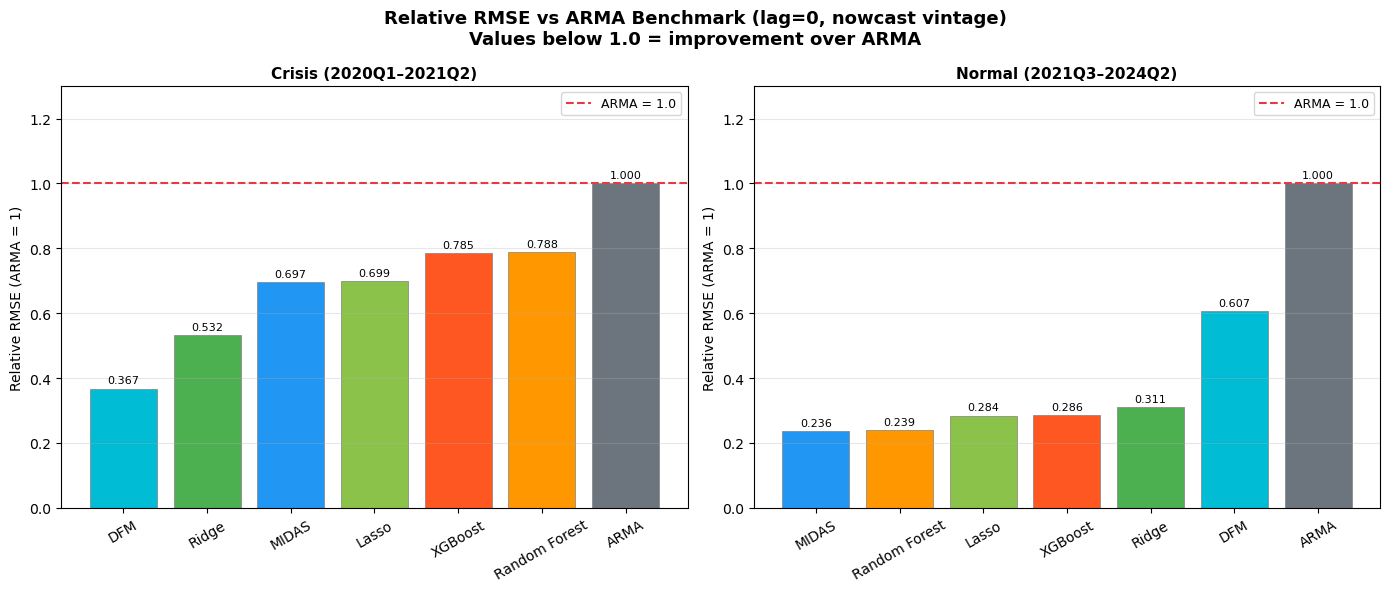

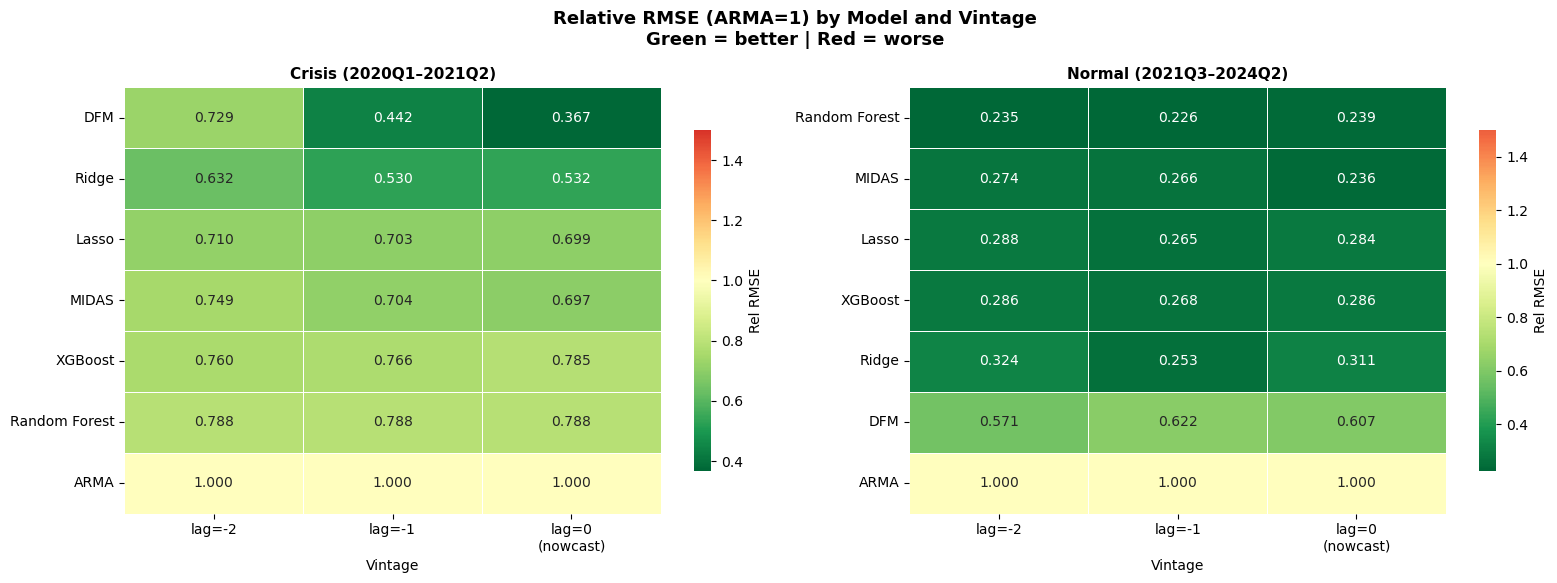

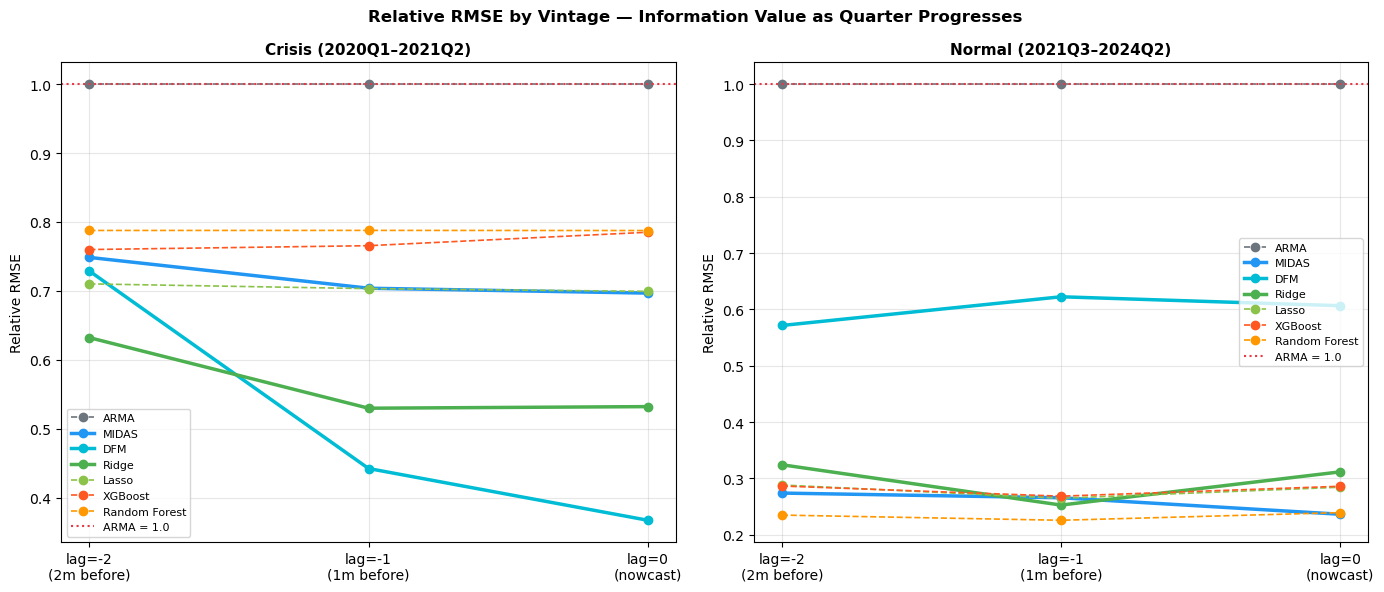

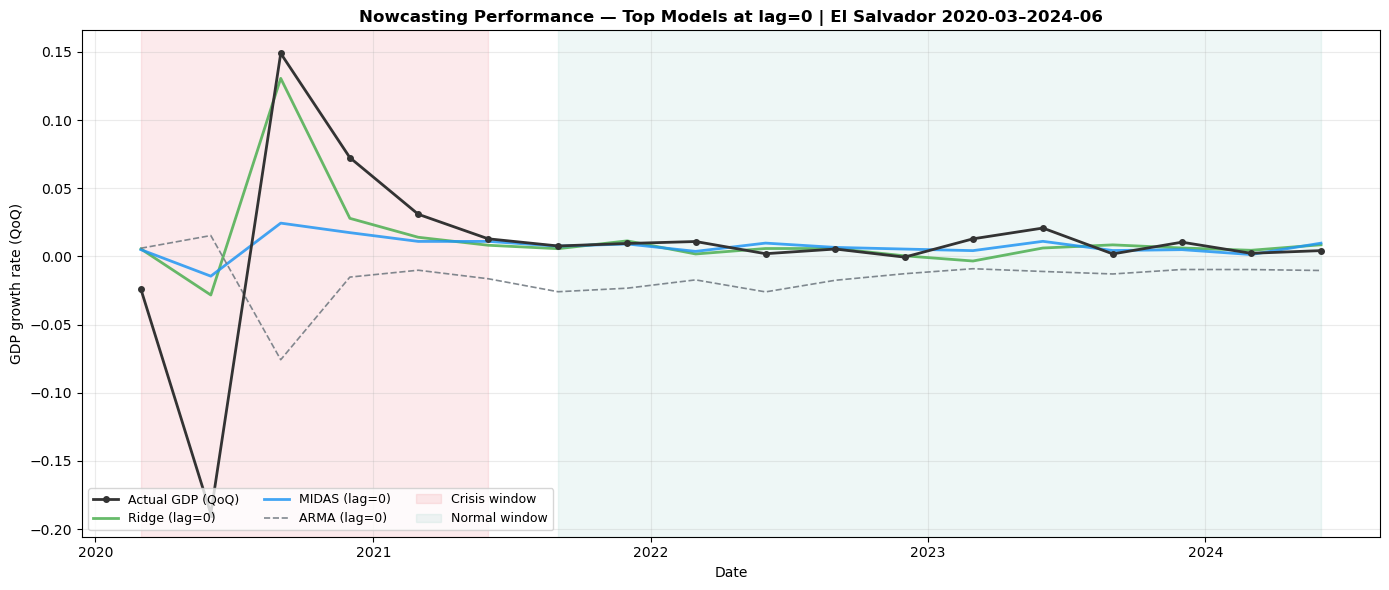

Plots saved to: /Users/gabrielaaquino/Desktop/ESA-gdp-nowcasting/Models/results/comparison


In [7]:
# =============================================================================
# PLOT 1 — Relative RMSE bar chart (lag=0) | crisis vs normal
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
fig.suptitle(
    "Relative RMSE vs ARMA Benchmark (lag=0, nowcast vintage)\n"
    "Values below 1.0 = improvement over ARMA",
    fontsize=13, fontweight="bold"
)
for ax, period, title in zip(
    axes,
    ["crisis", "normal"],
    ["Crisis (2020Q1–2021Q2)", "Normal (2021Q3–2024Q2)"]
):
    sub    = perf_raw[(perf_raw["period"] == period) &
                      (perf_raw["vintage"] == 0)].sort_values("rel_RMSE")
    colors = [MODEL_COLORS.get(m, "#888") for m in sub["model"]]
    bars   = ax.bar(sub["display"], sub["rel_RMSE"],
                    color=colors, edgecolor="gray", lw=0.5)
    ax.axhline(1.0, color="#e63946", lw=1.5, ls="--", label="ARMA = 1.0")
    for bar, val in zip(bars, sub["rel_RMSE"]):
        if not pd.isna(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("Relative RMSE (ARMA = 1)")
    max_val = sub["rel_RMSE"].max() if not sub["rel_RMSE"].isna().all() else 1.3
    ax.set_ylim(0, max(max_val * 1.2, 1.3))
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(OUT_COMP / "plot1_rmse_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# =============================================================================
# PLOT 2 — Heatmap: relative RMSE by model x vintage (crisis and normal)
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(loaded_models) * 0.7 + 1)))
fig.suptitle("Relative RMSE (ARMA=1) by Model and Vintage\n"
             "Green = better | Red = worse",
             fontsize=13, fontweight="bold")
for ax, period, title in zip(
    axes, ["crisis", "normal"],
    ["Crisis (2020Q1–2021Q2)", "Normal (2021Q3–2024Q2)"]
):
    sub   = (perf_raw[(perf_raw["period"] == period) &
                      (perf_raw["vintage"].isin(LAGS))]
             [["display", "vintage", "rel_RMSE"]].copy())
    pivot = sub.pivot(index="display", columns="vintage", values="rel_RMSE")
    pivot.columns = [VINTAGE_LABELS.get(c, str(c)) for c in pivot.columns]
    pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]
    vmin = min(0.5, pivot.min().min())
    vmax = max(1.5, pivot.max().max())
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn_r",
                center=1.0, vmin=vmin, vmax=vmax,
                linewidths=0.5, ax=ax,
                cbar_kws={"label": "Rel RMSE", "shrink": 0.8})
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Vintage")
    ax.set_ylabel("")
plt.tight_layout()
fig.savefig(OUT_COMP / "plot2_heatmap_rel_rmse.png", dpi=150, bbox_inches="tight")
plt.show()

# =============================================================================
# PLOT 3 — Vintage profiles: how RMSE changes from lag=-2 to lag=0
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Relative RMSE by Vintage — Information Value as Quarter Progresses",
             fontsize=12, fontweight="bold")
for ax, period, title in zip(
    axes, ["crisis", "normal"],
    ["Crisis (2020Q1–2021Q2)", "Normal (2021Q3–2024Q2)"]
):
    sub = perf_raw[perf_raw["period"] == period]
    for model_name in loaded_models:
        m_sub = sub[sub["model"] == model_name].sort_values("vintage")
        lw    = 2.5 if model_name in ["Ridge", "MIDAS", "DFM"] else 1.2
        ls    = "-"  if model_name in ["Ridge", "MIDAS", "DFM"] else "--"
        ax.plot(m_sub["vintage"], m_sub["rel_RMSE"],
                color=MODEL_COLORS.get(model_name, "#888"),
                lw=lw, ls=ls, marker="o", markersize=6,
                label=DISPLAY_NAMES.get(model_name, model_name))
    ax.axhline(1.0, color="#e63946", lw=1.5, ls=":", label="ARMA = 1.0")
    ax.set_xticks(LAGS)
    ax.set_xticklabels(["lag=-2\n(2m before)", "lag=-1\n(1m before)",
                         "lag=0\n(nowcast)"])
    ax.set_ylabel("Relative RMSE")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_COMP / "plot3_vintage_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

# =============================================================================
# PLOT 4 — Actual vs predicted (top models, lag=0, full period)
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 6))
dates_dt = pd.to_datetime(dates)
ax.plot(dates_dt, actuals, color="#333", lw=2, marker="o", markersize=4,
        label="Actual GDP (QoQ)", zorder=5)
for m in ["Ridge", "MIDAS", "ARMA"]:
    if m not in loaded_models:
        continue
    ax.plot(dates_dt, all_preds[m][0],
            color=MODEL_COLORS[m], lw=2.0 if m != "ARMA" else 1.2,
            ls="-" if m != "ARMA" else "--",
            label=f"{DISPLAY_NAMES.get(m, m)} (lag=0)", alpha=0.85)
ax.axvspan(pd.to_datetime(CRISIS_START), pd.to_datetime(CRISIS_END),
           alpha=0.10, color="#e63946", label="Crisis window")
ax.axvspan(pd.to_datetime(NORMAL_START), pd.to_datetime(NORMAL_END),
           alpha=0.08, color="#2a9d8f", label="Normal window")
ax.set_xlabel("Date")
ax.set_ylabel("GDP growth rate (QoQ)")
ax.set_title("Nowcasting Performance — Top Models at lag=0 | "
             f"El Salvador {TEST_START[:7]}–{TEST_END[:7]}",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9, ncol=3, loc="lower left")
ax.grid(True, alpha=0.25)
format_xaxis(ax)
plt.tight_layout()
fig.savefig(OUT_COMP / "plot4_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plots saved to:", OUT_COMP)


## Block 8 — Model Ranking Table

In [8]:
# =============================================================================
# MODEL RANKING — summary table (paper-ready)
# =============================================================================

ranking_rows = []
for model_name in loaded_models:
    sub = perf_raw[perf_raw["model"] == model_name]
    def _pick(period, vintage, col="rel_RMSE"):
        v = sub[(sub["period"] == period) & (sub["vintage"] == vintage)][col].values
        return v[0] if len(v) > 0 else np.nan
    ranking_rows.append({
        "Model":                  DISPLAY_NAMES.get(model_name, model_name),
        "Category":               MODEL_REGISTRY[model_name]["category"],
        "Crisis RMSE (lag=0)":    _pick("crisis", 0),
        "Normal RMSE (lag=0)":    _pick("normal", 0),
        "Full RMSE (lag=0)":      _pick("full",   0),
        "Crisis avg (all lags)":  round(sub[sub["period"] == "crisis"]["rel_RMSE"].mean(), 4),
        "Normal avg (all lags)":  round(sub[sub["period"] == "normal"]["rel_RMSE"].mean(), 4),
    })

ranking = pd.DataFrame(ranking_rows).sort_values("Crisis RMSE (lag=0)").round(4)
ranking.to_csv(OUT_COMP / "model_ranking.csv", index=False)
print("MODEL RANKING — sorted by Crisis RMSE (lag=0):")
print(ranking.to_string(index=False))


MODEL RANKING — sorted by Crisis RMSE (lag=0):
        Model     Category  Crisis RMSE (lag=0)  Normal RMSE (lag=0)  Full RMSE (lag=0)  Crisis avg (all lags)  Normal avg (all lags)
          DFM  econometric               0.3672               0.6065             0.3867                 0.5128                 0.6001
        Ridge    ml_linear               0.5321               0.3115             0.5210                 0.5647                 0.2960
        MIDAS  econometric               0.6968               0.2362             0.6772                 0.7164                 0.2585
        Lasso    ml_linear               0.6994               0.2842             0.6808                 0.7043                 0.2790
      XGBoost ml_nonlinear               0.7851               0.2859             0.7635                 0.7702                 0.2802
Random Forest ml_nonlinear               0.7876               0.2391             0.7648                 0.7877                 0.2331
         ARMA  

## Block 9 — Diebold-Mariano Significance Tests

Uses the canonical `diebold_mariano_test` from `nowcast_utils.py`, which
implements the Harvey-Leybourne-Newbold (1997) small-sample correction.
Test is **one-sided**: `H1 = the tested model has lower MSPE than the benchmark`.
Negative DM statistic means the tested model beats the benchmark.


In [9]:
# =============================================================================
# DIEBOLD-MARIANO TEST — one-sided, HLN-corrected (from nowcast_utils.py)
#
# For each benchmark in BENCHMARKS, for each remaining model, for each
# period, run DM(model vs benchmark) at lag=0.
#
# The utils function returns:
#   DM_stat      : classical DM statistic (no HLN correction)
#   DM_stat_HLN  : HLN-adjusted statistic (reported in tables)
#   p_value      : one-sided p-value from t_{n-1} on HLN stat
#   RMSE_benchmark, RMSE_model, n_obs
# =============================================================================

IN_FILE = OUT_COMP / "unified_predictions.csv"
if not IN_FILE.exists():
    raise FileNotFoundError("Run Block 6 first — unified_predictions.csv not found.")

df_uni = (pd.read_csv(IN_FILE, parse_dates=["date"])
          .sort_values("date").reset_index(drop=True))
actuals_ = df_uni["actual"].values
periods_ = df_uni["period_type"].values

# Period masks directly from 'period_type' column (single source of truth)
mask_full_   = np.ones(len(actuals_), dtype=bool)
mask_crisis_ = (periods_ == "crisis")
mask_normal_ = (periods_ == "normal")

# Load lag=0 predictions for each model
DM_MODELS = ["ARMA", "DFM", "Ridge", "MIDAS", "Lasso", "Random Forest", "XGBoost"]
model_preds_ = {}
for m in DM_MODELS:
    col = f"{m}_lag{NOWCAST_LAG}"
    if col in df_uni.columns:
        model_preds_[m] = df_uni[col].values

available_dm = list(model_preds_.keys())
print(f"Models available for DM: {available_dm}")

def stars(p):
    if pd.isna(p):      return ""
    if p < ALPHA_10:    return "***"
    if p < ALPHA_5:     return "**"
    if p < ALPHA_1:     return "*"
    return ""

def dm_one_period(pred_model, pred_benchmark, y_true, mask):
    """Run DM for one benchmark-model-period combination. Returns dict."""
    y_m = y_true[mask]; p_m = pred_model[mask]; b_m = pred_benchmark[mask]
    valid = ~np.isnan(y_m) & ~np.isnan(p_m) & ~np.isnan(b_m)
    if valid.sum() < 5:
        return {"DM_stat": np.nan, "DM_stat_HLN": np.nan, "p_value": np.nan,
                "n_obs": int(valid.sum()),
                "RMSE_benchmark": np.nan, "RMSE_model": np.nan}
    return diebold_mariano_test(y_m[valid], b_m[valid], p_m[valid], h=1)

# Run all benchmark comparisons
all_dm = []
for bench in BENCHMARKS:
    if bench not in available_dm:
        continue
    for mask, label in [
        (mask_full_,   f"Full ({TEST_START[:7]}–{TEST_END[:7]})"),
        (mask_crisis_, "Crisis (2020Q1–2021Q2)"),
        (mask_normal_, "Normal (2021Q3–2024Q2)"),
    ]:
        for model in available_dm:
            if model == bench:
                continue
            res = dm_one_period(
                model_preds_[model], model_preds_[bench], actuals_, mask
            )
            all_dm.append({
                "Model":         model,
                "vs":            bench,
                "Period":        label,
                "T":             res["n_obs"],
                "DM_stat":       res["DM_stat"],
                "DM_stat_HLN":   res["DM_stat_HLN"],
                "p_value":       res["p_value"],
                "Stars":         stars(res["p_value"]),
                "RMSE_model":    res["RMSE_model"],
                "RMSE_bench":    res["RMSE_benchmark"],
                # With H1 = model beats benchmark:
                # DM_stat_HLN < 0 AND p_value < ALPHA → tested model IS better
                "Better":        "YES" if (
                    not pd.isna(res["DM_stat_HLN"]) and res["DM_stat_HLN"] < 0
                ) else "NO",
            })

dm_all = pd.DataFrame(all_dm)
dm_all.to_csv(OUT_DM / "dm_all_results.csv", index=False)

# Print publication summary
for bench in BENCHMARKS:
    print(f"\n{'='*70}")
    print(f"DM TEST vs {bench} | lag=0 | HLN-corrected, one-sided (H1: model better)")
    print(f"{'='*70}")
    for period in [f"Full ({TEST_START[:7]}–{TEST_END[:7]})",
                   "Crisis (2020Q1–2021Q2)",
                   "Normal (2021Q3–2024Q2)"]:
        sub = dm_all[(dm_all["vs"] == bench) & (dm_all["Period"] == period)]
        if sub.empty:
            continue
        print(f"\n  {period}:")
        print(sub[["Model", "T", "DM_stat_HLN", "Stars", "p_value", "Better"]]
              .to_string(index=False))
print("\nSaved: dm_all_results.csv")


Models available for DM: ['ARMA', 'DFM', 'Ridge', 'MIDAS', 'Lasso', 'Random Forest', 'XGBoost']

DM TEST vs ARMA | lag=0 | HLN-corrected, one-sided (H1: model better)

  Full (2020-03–2024-06):
        Model  T  DM_stat_HLN Stars  p_value Better
          DFM 18       1.6499     *   0.0587     NO
        Ridge 18       1.5312     *   0.0721     NO
        MIDAS 18       1.6379     *   0.0599     NO
        Lasso 18       1.5050     *   0.0753     NO
Random Forest 18       1.5848     *   0.0657     NO
      XGBoost 18       1.6777     *   0.0558     NO

  Crisis (2020Q1–2021Q2):
        Model  T  DM_stat_HLN Stars  p_value Better
          DFM  6       1.6516     *   0.0798     NO
        Ridge  6       1.4184         0.1076     NO
        MIDAS  6       1.4711         0.1006     NO
        Lasso  6       1.3243         0.1213     NO
Random Forest  6       1.3364         0.1195     NO
      XGBoost  6       1.4466         0.1038     NO

  Normal (2021Q3–2024Q2):
        Model  T  DM_sta

## Block 10 — Pairwise DM Heatmaps

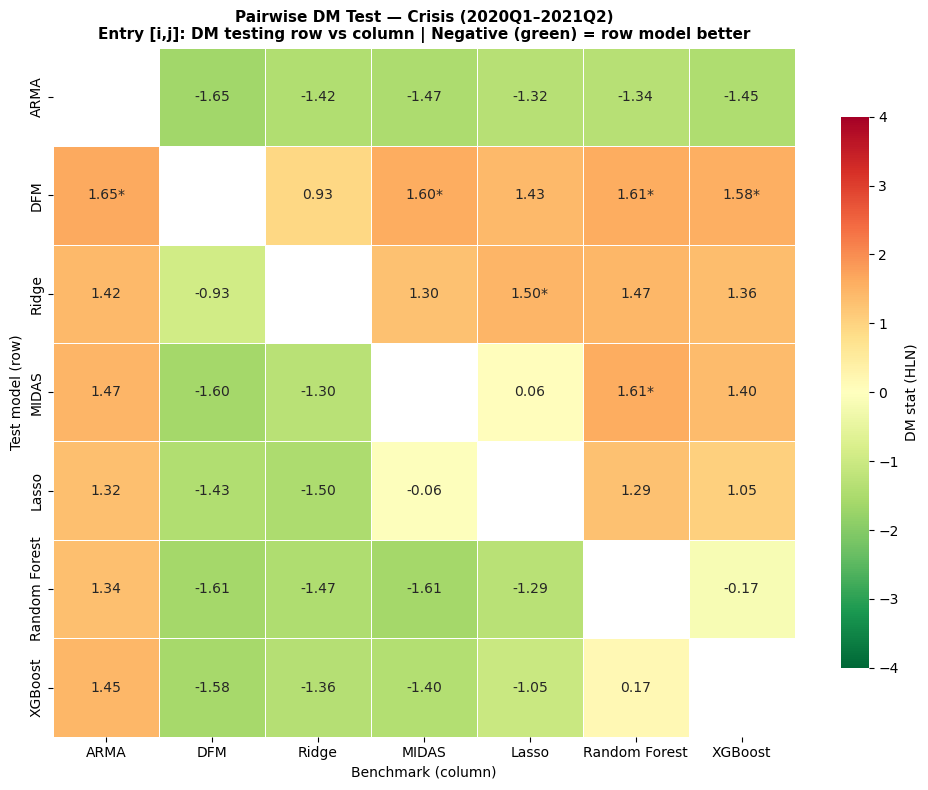

Saved: dm_heatmap_crisis.png


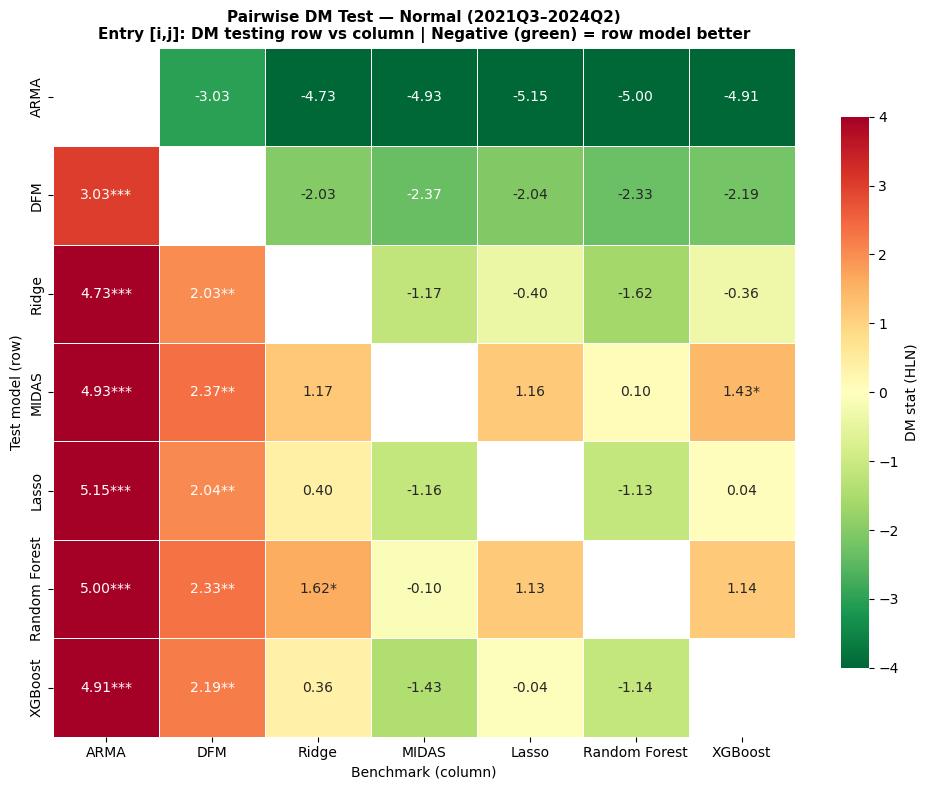

Saved: dm_heatmap_normal.png


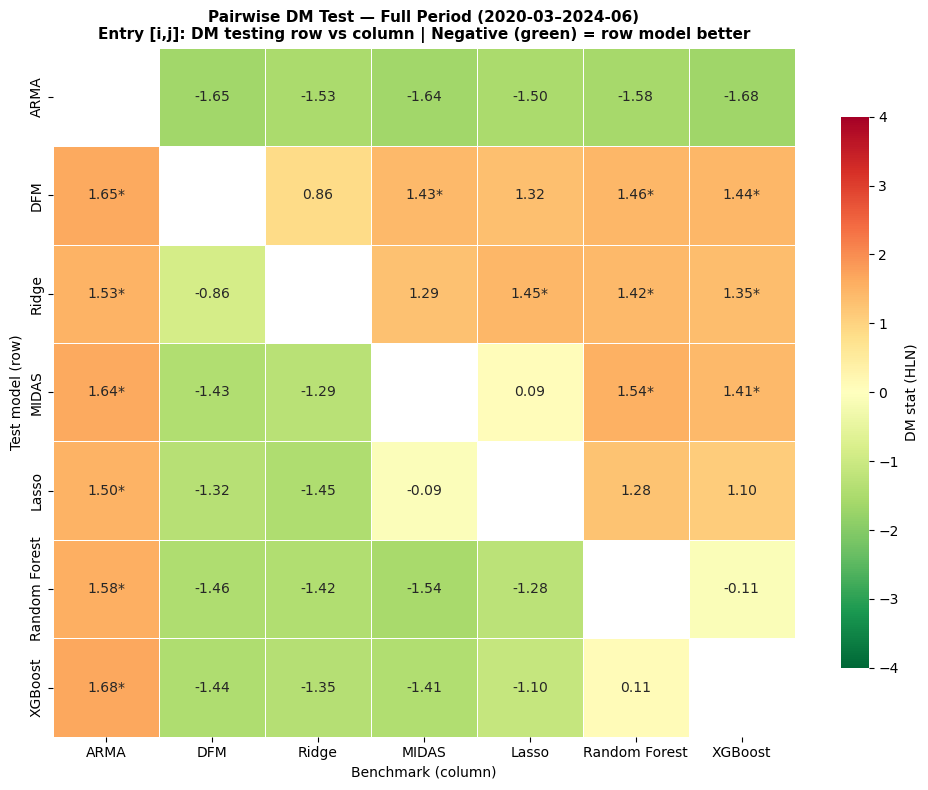

Saved: dm_heatmap_full.png

All DM outputs saved to: /Users/gabrielaaquino/Desktop/ESA-gdp-nowcasting/Models/results/diebold_mariano

Notebook 01 COMPLETE. Next: run 02_density_and_interpretability.ipynb


In [10]:
# =============================================================================
# PAIRWISE DM — full (model x model) matrix per period
# Entry [i,j] = DM_stat_HLN for row (test) vs column (benchmark)
# Negative (green) = row model beats column model
# =============================================================================

def pairwise_dm(models, mask):
    n = len(models)
    S = np.full((n, n), np.nan)
    P = np.full((n, n), np.nan)
    for i, m1 in enumerate(models):
        for j, m2 in enumerate(models):
            if i == j:
                continue
            res = dm_one_period(model_preds_[m1], model_preds_[m2],
                                actuals_, mask)
            S[i, j] = res["DM_stat_HLN"]
            P[i, j] = res["p_value"]
    return (pd.DataFrame(S, index=models, columns=models),
            pd.DataFrame(P, index=models, columns=models))

for mask, label, fname in [
    (mask_crisis_, "Crisis (2020Q1–2021Q2)",
     "dm_heatmap_crisis.png"),
    (mask_normal_, "Normal (2021Q3–2024Q2)",
     "dm_heatmap_normal.png"),
    (mask_full_,   f"Full Period ({TEST_START[:7]}–{TEST_END[:7]})",
     "dm_heatmap_full.png"),
]:
    S_df, P_df = pairwise_dm(available_dm, mask)
    annot = S_df.copy().astype(object)
    for i in range(len(available_dm)):
        for j in range(len(available_dm)):
            if i == j:
                annot.iloc[i, j] = "—"
            else:
                v, p = S_df.iloc[i, j], P_df.iloc[i, j]
                annot.iloc[i, j] = "—" if pd.isna(v) else f"{v:.2f}{stars(p)}"

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(S_df.astype(float), annot=annot, fmt="",
                cmap="RdYlGn_r", center=0, vmin=-4, vmax=4,
                linewidths=0.5, ax=ax,
                cbar_kws={"label": "DM stat (HLN)", "shrink": 0.8})
    ax.set_title(f"Pairwise DM Test — {label}\n"
                 "Entry [i,j]: DM testing row vs column | "
                 "Negative (green) = row model better",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Benchmark (column)")
    ax.set_ylabel("Test model (row)")
    plt.tight_layout()
    fig.savefig(OUT_DM / fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

# Save vs-each-benchmark publication table
for bench in BENCHMARKS:
    rows_pub = []
    for m in DM_MODELS:
        if m == bench or m not in available_dm:
            continue
        row = {"Model": m}
        for p_label in [f"Full ({TEST_START[:7]}–{TEST_END[:7]})",
                        "Crisis (2020Q1–2021Q2)",
                        "Normal (2021Q3–2024Q2)"]:
            sub = dm_all[(dm_all["vs"] == bench) &
                         (dm_all["Model"] == m) &
                         (dm_all["Period"] == p_label)]
            if sub.empty:
                row[p_label] = "—"
            else:
                v  = sub["DM_stat_HLN"].values[0]
                pv = sub["p_value"].values[0]
                row[p_label] = "—" if pd.isna(v) else f"{v:.3f}{stars(pv)}"
        rows_pub.append(row)
    tbl = pd.DataFrame(rows_pub)
    tbl.to_csv(OUT_DM / f"dm_table_vs{bench}.csv", index=False)

print("\nAll DM outputs saved to:", OUT_DM)
print("\nNotebook 01 COMPLETE. Next: run 02_density_and_interpretability.ipynb")
